# Session 2 — Visualization for Finance Insight

## Goals
- Create interpretable plots for financial data
- Compare stock behavior using visualization
- Practice explaining financial insights

## Expected Output

An EDA notebook with:

• Price trend plot  
• Daily returns plot  
• Return distribution plot  
• Correlation heatmap  
• Short interpretation notes

## 1. Import Libraries
We import libraries used for data analysis and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use("seaborn-v0_8")

## 2. Download Market Data

We will analyze two stocks:

AAPL → Apple  
TSLA → Tesla  

Having two stocks allows us to compare behavior.

In [ ]:
tickers = ["AAPL", "TSLA"]

data = yf.download(tickers, start="2022-01-01", progress=False)["Close"]

data.head()

/tmp/ipykernel_7215/2640730087.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2022-01-01", progress=False)["Close"]


Ticker,AAPL,TSLA
Date,,
2022-01-03,178.103683,399.926666
2022-01-04,175.843231,383.196655
2022-01-05,171.165817,362.706665
2022-01-06,168.308502,354.899994
2022-01-07,168.474823,342.320007


### Exercise 1

Download data for **two additional stocks** of your choice.

Examples:

• NVDA  
• MSFT  
• AMZN  

Store them in a variable called `extra_data`.

In [ ]:
extra_tickers = ["NVDA", "MSFT", "AMZN"]

extra_data = yf.download(extra_tickers, start="2022-01-01", progress=False)["Close"]
extra_data.head()

/tmp/ipykernel_8857/3126185233.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  extra_data = yf.download(extra_tickers, start="2022-01-01", progress=False)["Close"]


Ticker,AMZN,MSFT,NVDA
Date,,,
2022-01-03,170.404495,323.160736,30.061136
2022-01-04,167.522003,317.619507,29.231789
2022-01-05,164.356995,305.426727,27.549139
2022-01-06,163.253998,303.013367,28.122004
2022-01-07,162.554001,303.167725,27.192848


In [ ]:
extra_data.isna()

Ticker,AMZN,MSFT,NVDA
Date,,,
2022-01-03,False,False,False
2022-01-04,False,False,False
2022-01-05,False,False,False
2022-01-06,False,False,False
2022-01-07,False,False,False
...,...,...,...
2026-03-13,False,False,False
2026-03-16,False,False,False
2026-03-17,False,False,False


## 3. Clean the Data

Real datasets may contain missing values.

We remove them before analysis.

In [ ]:
data = data.dropna()

data.head()

Ticker,AAPL,TSLA
Date,,
2022-01-03,178.103683,399.926666
2022-01-04,175.843231,383.196655
2022-01-05,171.165817,362.706665
2022-01-06,168.308502,354.899994
2022-01-07,168.474823,342.320007


### Exercise 2

Check if the dataset contains missing values.

Hint: use `.isna()`

In [ ]:
# your code here

## 4. Plot Price Trends

Investors use price trends to understand long-term growth and momentum.

Price plots help us understand long‑term trends.

Questions to think about:

• Which stock increased the most?  
• Which stock had bigger price swings?

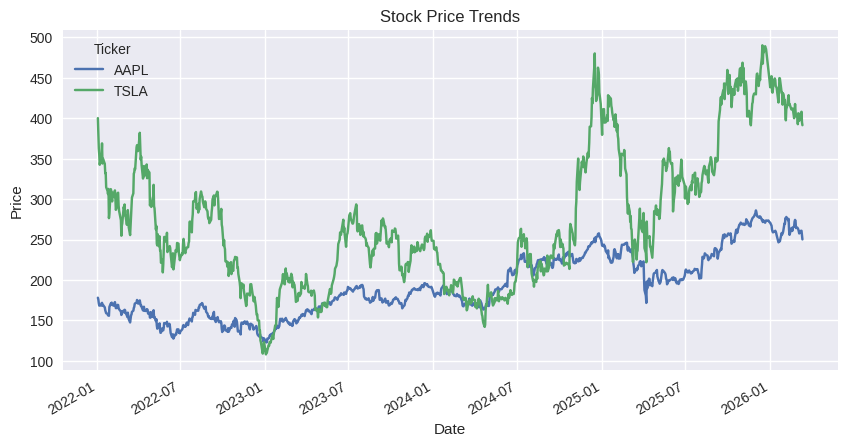

In [ ]:
data.plot(figsize=(10,5))

plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

### Exercise 3
Create a price plot for **only TSLA**.

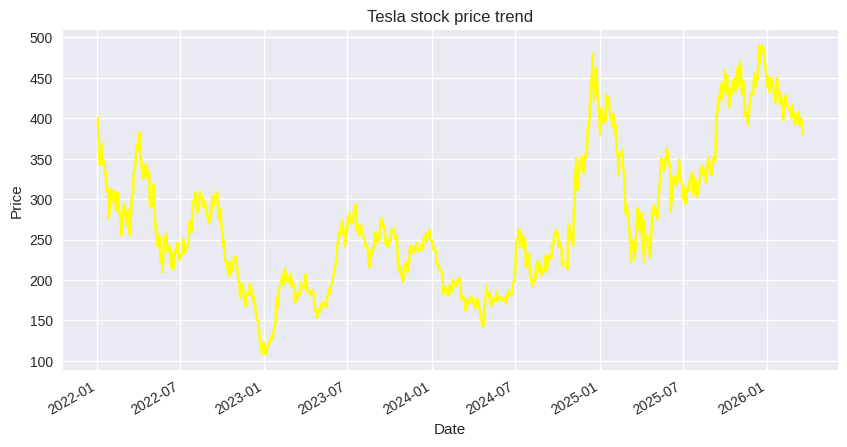

In [ ]:
data["TSLA"].plot(figsize=(10,5),color="yellow")

plt.title("Tesla stock price trend")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

### Interpretation

Write 2‑3 sentences describing what you observe.

Example:

TSLA shows larger price swings than AAPL.  
This matters because larger swings often indicate higher volatility.

## 5. Compute Daily Returns

In [ ]:
returns = data.pct_change().dropna()

returns.head()

Ticker,AAPL,TSLA
Date,,
2022-01-04,-0.012692,-0.041833
2022-01-05,-0.026600,-0.053471
2022-01-06,-0.016693,-0.021523
2022-01-07,0.000988,-0.035447
2022-01-10,0.000116,0.030342


### Exercise 4
Calculate returns for the extra stocks you downloaded earlier.

In [ ]:
extra_returns = extra_data.pct_change().dropna()
extra_returns.head()

Ticker,AMZN,MSFT,NVDA
Date,,,
2022-01-04,-0.016916,-0.017147,-0.027589
2022-01-05,-0.018893,-0.038388,-0.057562
2022-01-06,-0.006711,-0.007902,0.020794
2022-01-07,-0.004288,0.000509,-0.033040
2022-01-10,-0.006570,0.000733,0.005615


## 6. Plot Daily Returns
Returns help us see volatility more clearly than prices.

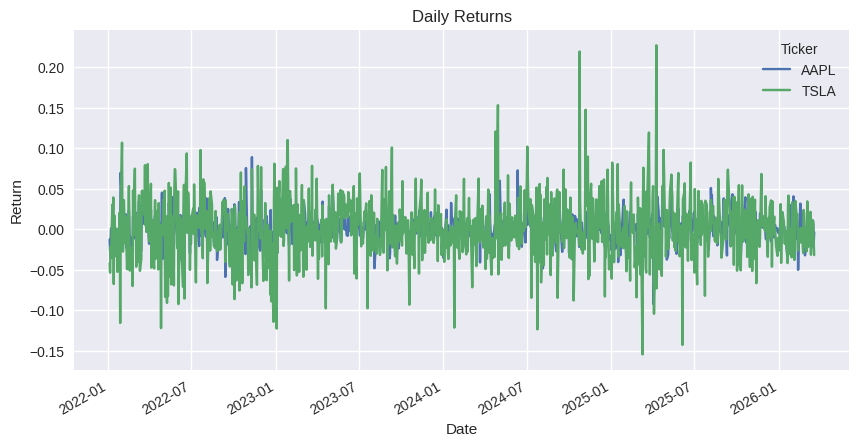

In [ ]:
returns.plot(figsize=(10,5))

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

### Exercise 5
Plot the daily returns for only **AAPL**.

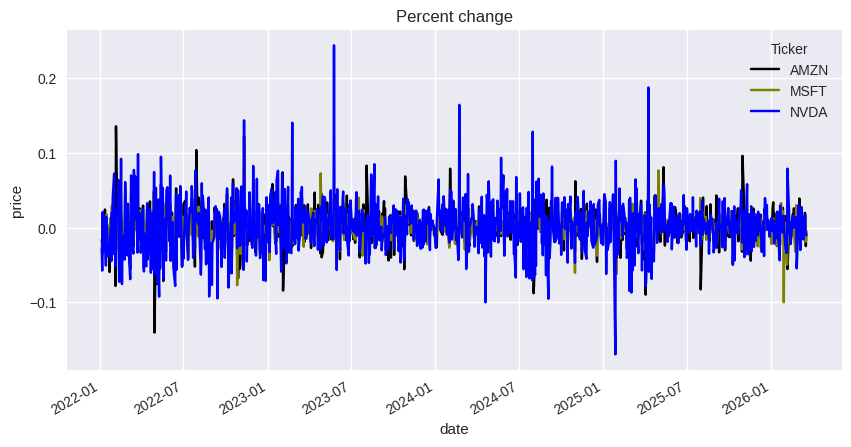

In [ ]:
extra_returns.plot(figsize=(10,5),color=["black","Olive","Blue"])
plt.title("Percent change")
plt.xlabel("date")
plt.ylabel("price")

plt.show()

### Interpretation
Which stock appears more volatile?

## 7. Distribution of Returns
Returns normalize price movement and allow fair comparison between stocks.

A distribution plot shows how returns are spread.

Wide distribution → higher volatility.

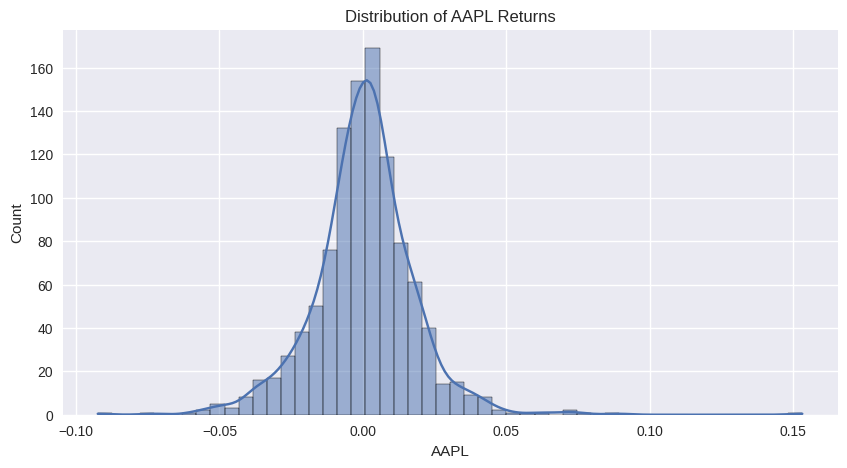

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(returns["AAPL"], bins=50, kde=True)
plt.title("Distribution of AAPL Returns")

plt.show()

### Exercise 6
Create a distribution plot for **TSLA returns**.

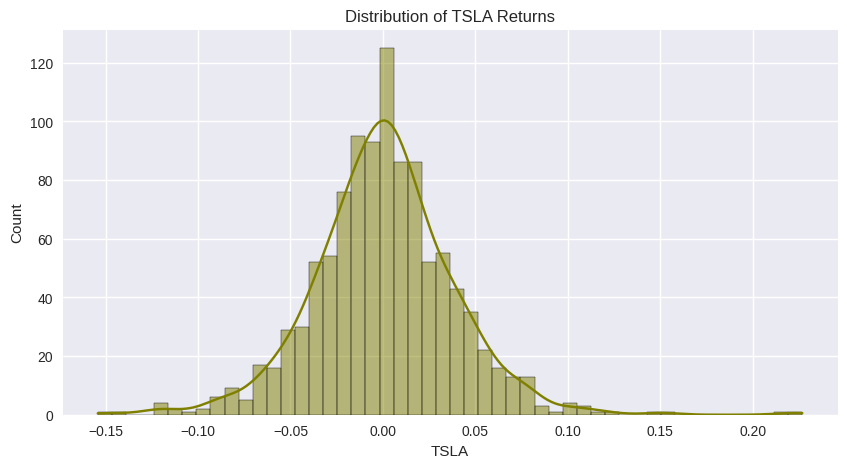

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(returns["TSLA"], bins=50, kde=True, color="olive")
plt.title("Distribution of TSLA Returns")

plt.show()

## 8. Correlation Between Stocks
Correlation tells us how assets move relative to each other.

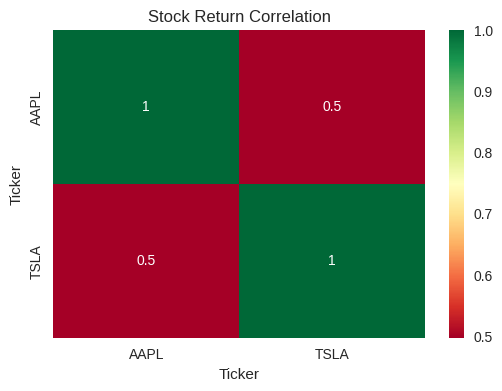

In [ ]:
corr = returns.corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="RdYlGn")

plt.title("Stock Return Correlation")

plt.show()
#[-1,1]

### Exercise 7
Print the correlation matrix using `.corr()`.

In [ ]:
# your code here
print(corr)

Ticker      AAPL      TSLA
Ticker                    
AAPL    1.000000  0.496874
TSLA    0.496874  1.000000


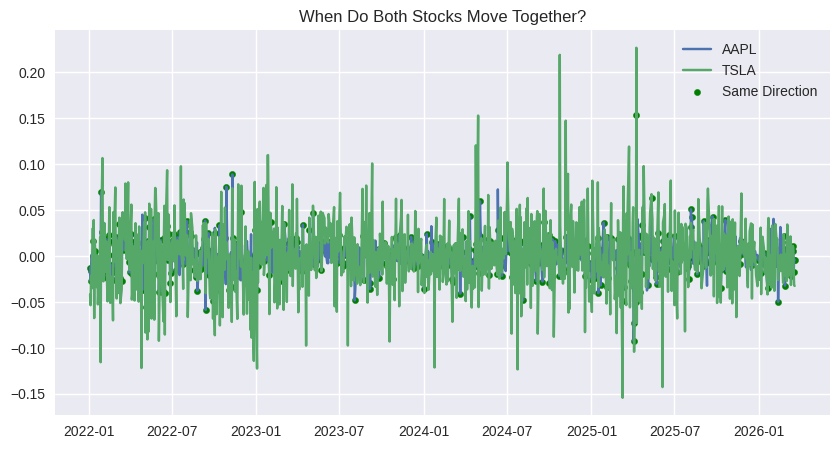

In [ ]:
same_direction = (returns['AAPL'] * returns['TSLA']) > 0

plt.figure(figsize=(10,5))
plt.plot(returns.index, returns['AAPL'], label='AAPL')
plt.plot(returns.index, returns['TSLA'], label='TSLA')

# highlight same direction days
plt.scatter(
    returns.index[same_direction],
    returns['AAPL'][same_direction],
    color='green',
    label='Same Direction',
    s=20
)

plt.legend()
plt.title("When Do Both Stocks Move Together?")
plt.show()

### What is Volatility?

Volatility measures how much a stock's returns fluctuate over time.

• High volatility → large swings → higher risk  
• Low volatility → stable movement → lower risk  

Instead of a single number, we calculate **rolling volatility** to see how risk changes over time.

In [ ]:
# Calculate rolling volatility (20-day window)
rolling_vol = returns.rolling(window=20).std()

# Plot
rolling_vol.plot(figsize=(12,6))
plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (Std of Returns)")
plt.show()

### 📌 How to Interpret This

• Spikes → periods of high uncertainty or market stress  
• Flat/low regions → stable market periods  
• Compare between stocks:
    - Which stock is more volatile?
    - When did risk increase?

👉 This helps investors understand *when* a stock becomes risky — not just *how much*.

### Exercise: Analyze Volatility

1. Which stock shows the highest volatility overall?
2. Identify a time period where volatility spikes — what might have caused it?
3. Which stock seems more stable over time?

💡 Bonus: Do you think higher volatility means higher returns?

Exercies

In [ ]:
tickers = ["SLB", "HAL"]

oil_data = yf.download(tickers, start="2022-01-01", progress=False)["Close"]

oil_data.head()

/tmp/ipykernel_7215/973122264.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(tickers, start="2022-01-01", progress=False)["Close"]


Ticker,HAL,SLB
Date,,
2022-01-03,21.995661,28.821686
2022-01-04,23.315956,30.220972
2022-01-05,23.086739,30.220972
2022-01-06,23.480991,30.938784
2022-01-07,23.856911,31.829243


In [ ]:
oil_data.describe()

Ticker,HAL,SLB
count,1057.000000,1057.000000
mean,30.291389,42.198101
std,5.326833,6.859937
min,18.746059,28.659996
25%,26.512188,35.904850
50%,30.575089,41.757626
75%,34.753250,47.643406
max,40.761688,58.090500


In [ ]:
oil_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1057 entries, 2022-01-03 to 2026-03-20
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HAL     1057 non-null   float64
 1   SLB     1057 non-null   float64
dtypes: float64(2)
memory usage: 24.8 KB


In [ ]:
oil_returns = oil_data.pct_change().dropna()
oil_returns.head()

Ticker,HAL,SLB
Date,,
2022-01-04,0.060025,0.048550
2022-01-05,-0.009831,0.000000
2022-01-06,0.017077,0.023752
2022-01-07,0.016010,0.028781
2022-01-10,-0.006534,0.002569


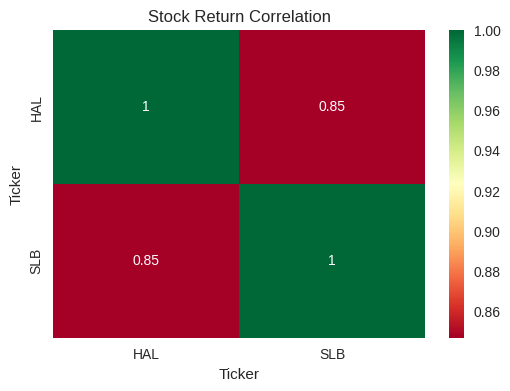

In [ ]:
oil_corr = oil_returns.corr()

plt.figure(figsize=(6,4))

sns.heatmap(oil_corr, annot=True, cmap="RdYlGn")

plt.title("Stock Return Correlation")

plt.show()
#[-1,1]